<a href="https://colab.research.google.com/github/baldiea75-tech/carisurg-portfolio/blob/main/week0_triage_eda_day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/carisurg-portfolio', exist_ok=True)
print("Folder ready!")

Folder ready!


# New section

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_raw = pd.read_csv('EmergencyTriageDataset_Reduced_Dirty.csv')
print(f"Dataset: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print(list(df_raw.columns))

Dataset: 2205 rows x 11 columns
['ID', 'Age', 'Gender', 'GCS', 'SBP', 'DBP', 'MAP', 'pulse', 'Temp', 'RR', 'Fio2']


In [ ]:
print(df_raw['Gender'].unique())
print(df_raw['Gender'].value_counts())

['0' 'Male' 'Female' 'FEMALE' '1' 'MALE']
Gender
1         422
MALE      379
Male      375
FEMALE    366
Female    340
0         323
Name: count, dtype: int64


In [ ]:
gender_map = {
      'Male':   1,  'MALE':   1,  '1': 1,
          'Female': 0,  'FEMALE': 0,  '0': 0
}
df_raw['Gender_Clean'] = df_raw['Gender'].map(gender_map)
print(df_raw['Gender_Clean'].value_counts())
print(f"NaNs: {df_raw['Gender_Clean'].isnull().sum()}")

Gender_Clean
1    1176
0    1029
Name: count, dtype: int64
NaNs: 0


In [ ]:
df_raw = df_raw.drop(columns=['Gender'])
df_raw = df_raw.rename(columns={'Gender_Clean': 'Gender'})
df_raw.head()

KeyError: "['Gender'] not found in axis"

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_raw)

https://docs.google.com/spreadsheets/d/1KVIuf15gYklCUgem4k_WryItlrYySzx9pIN3CWg_9D0/edit#gid=0


In [ ]:
## Day 1 — Gender column cleaning
- Found 6 variants: Male, MALE, 1, Female, FEMALE, 0
- Mapped all to binary: 1 = Male, 0 = Female
- Result: 1176 Male, 1029 Female, 0 missing values
- Used .map() so any unmapped value would show as NaN

# New section-Day 2

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
from google.colab import drive


# MOUNT DRIVE AND AUTO-LOCATE FILE

try:
    drive.mount("/content/drive")
    print("Drive mounted successfully!")
except Exception as e:
    print("Drive already mounted or running outside Colab.")

# Search Google Drive for the file name automatically
file_search_pattern = "/content/drive/MyDrive/carisurg-portfolio/EmergencyTriageDataset_Reduced_Dirty.csv"
matching_files = glob.glob(file_search_pattern, recursive=True)

if matching_files:
    FILE_PATH = matching_files[0]
    print(f" Found file automatically at: {FILE_PATH}")
else:
    # Fallback to local directory if Google Drive fails completely
    FILE_PATH = "EmergencyTriageDataset_Reduced_Dirty.csv"
    print("File not found in Drive folders")

# Load the dataframe
df = pd.read_csv(FILE_PATH)
print(f"Dataset loaded successfully: {df.shape[0]} rows x {df.shape[1]} columns")
print("=" * 60)


# PART 1: CARISURG BREAKOUT GROUP TEMPLATE — CLEANING THE PULSE COLUMN
COLUMN = "pulse"
VALID_MIN = 20  # Clinically justified minimum for pulse (Reference Table Page 15)
VALID_MAX = 250  # Clinically justified maximum for pulse (Reference Table Page 15)

print(f"=== Cleaning: {COLUMN} ===")
print(f"Original Unique values (Sample): {df[COLUMN].unique()[:15]}")
print(f"Original Dtype: {df[COLUMN].dtype}")
print("-" * 50)

# Convert to numeric, forcing text entry errors into NaNs
df[COLUMN] = pd.to_numeric(df[COLUMN], errors="coerce")
print(f"After type conversion — NaNs found: {df[COLUMN].isnull().sum()}")
print(df[COLUMN].describe())
print("-" * 50)

# Identify and isolate physiologically impossible outliers
invalid_pulse = df[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX)]
print(f"Out-of-range pulse values detected: {len(invalid_pulse)} rows")

# Convert out-of-range values to NaN
df.loc[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX), COLUMN] = np.nan
print(f"Total NaNs before imputation: {df[COLUMN].isnull().sum()}")
print("-" * 50)

# Impute missing entries with the median
impute_value_pulse = df[COLUMN].median()
df[COLUMN] = df[COLUMN].fillna(impute_value_pulse)

print(f"After Cleaning {COLUMN}:")
print(df[COLUMN].describe())
print(f"NaNs remaining: {df[COLUMN].isnull().sum()}")
print("=" * 60)


# PART 2: COMPANION CLEANING FOR SBP (needed for shock index)
print("\n=== Cleaning Companion Column: SBP ===")
COLUMN_SBP = "SBP"
VALID_MIN_SBP = 50
VALID_MAX_SBP = 250

# Convert and filter range
df[COLUMN_SBP] = pd.to_numeric(df[COLUMN_SBP], errors="coerce")
df.loc[
    (df[COLUMN_SBP] < VALID_MIN_SBP) | (df[COLUMN_SBP] > VALID_MAX_SBP),
    COLUMN_SBP,
] = np.nan

# Median Imputation
impute_value_sbp = df[COLUMN_SBP].median()
df[COLUMN_SBP] = df[COLUMN_SBP].fillna(impute_value_sbp)

print(df[COLUMN_SBP].describe())
print("=" * 60)


# ADVANCED CLINICAL RISK FEATURE ENGINEERING (SHOCK FLAG)
print("\n=== Composite Shock Flag ===")

# Create the binary composite flag safely using 1s and 0s
df["shock_flag"] = np.where((df["SBP"] < 90) & (df["pulse"] > 110), 1, 0)

print("--- Clinical Risk Assessment Matrix Complete ---")
print(f"Total Patient Records Audited: {len(df)}")
print(f"High-Risk Decompensated Shock Cases Identified: {df['shock_flag'].sum()}")
print(
    f"Percentage of At-Risk Population: {(df['shock_flag'].sum() / len(df)) * 100:.2f}%"
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!
 Found file automatically at: /content/drive/MyDrive/carisurg-portfolio/EmergencyTriageDataset_Reduced_Dirty.csv
Dataset loaded successfully: 2205 rows x 11 columns
=== Cleaning: pulse ===
Original Unique values (Sample): ['128.0' '80.0' '92.0' '100.0' '85.0' '99.0' '78.0' '130.0' '63.0' '98.0'
 '76.0' '166.0' '151.0' '94.0' '87.0']
Original Dtype: object
--------------------------------------------------
After type conversion — NaNs found: 44
count    2161.000000
mean       96.094863
std        31.035460
min         0.000000
25%        80.000000
50%        90.000000
75%       108.000000
max       300.000000
Name: pulse, dtype: float64
--------------------------------------------------
Out-of-range pulse values detected: 43 rows
Total NaNs before imputation: 87
--------------------------------------------------
After Cleaning pulse

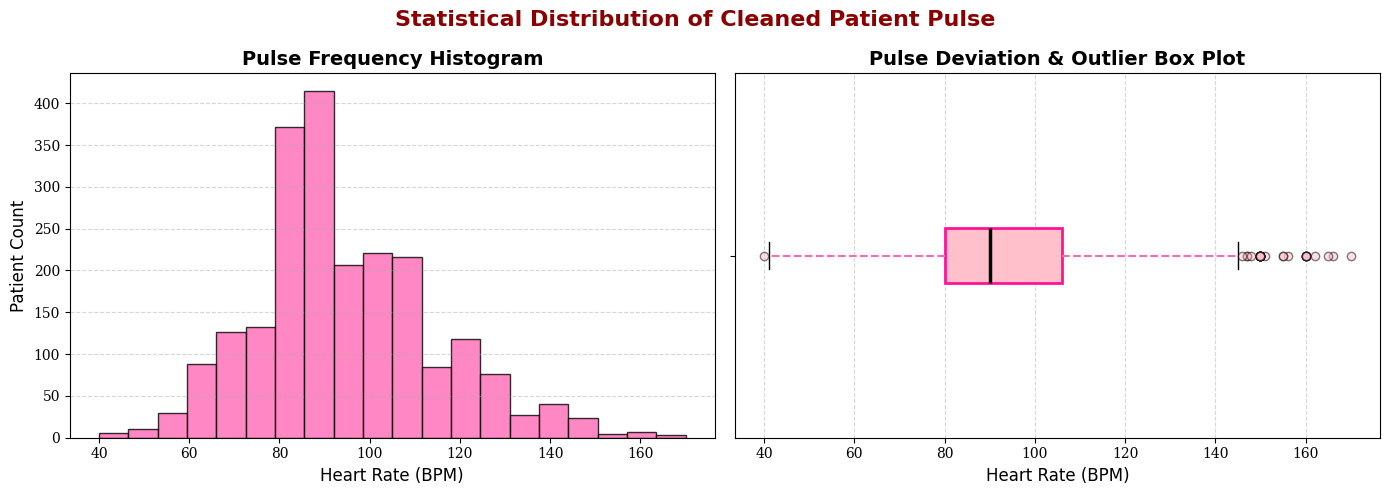

In [ ]:
import matplotlib.pyplot as plt

# Set global font to Times New Roman style
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

# Create a clean, side-by-side plotting area
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Statistical Distribution of Cleaned Patient Pulse",
    fontsize=16,
    fontname="Times New Roman",
    weight="bold",
    color="darkred",
)

# GRAPH 1: HISTOGRAM (Distribution Count)
axes[0].hist(
    df["pulse"], bins=20, edgecolor="black", color="hotpink", alpha=0.8
)
axes[0].set_title(
    "Pulse Frequency Histogram",
    fontsize=14,
    fontname="Times New Roman",
    weight="bold",
)
axes[0].set_xlabel(
    "Heart Rate (BPM)", fontsize=12, fontname="Times New Roman"
)
axes[0].set_ylabel(
    "Patient Count", fontsize=12, fontname="Times New Roman"
)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# GRAPH 2: DEVIATION BOX PLOT (Visualizing Spread & Variances)
# Custom styling of the box plot markers
box_props = dict(linestyle="-", linewidth=2, color="deeppink")
whisker_props = dict(linestyle="--", linewidth=1.5, color="hotpink")
median_props = dict(linestyle="-", linewidth=2.5, color="black")
flier_props = dict(marker="o", markerfacecolor="pink", markersize=6, alpha=0.5)

axes[1].boxplot(
    df["pulse"],
    vert=False,
    patch_artist=True,
    boxprops=box_props,
    whiskerprops=whisker_props,
    medianprops=median_props,
    flierprops=flier_props,
)

# Color the interior of the box pink
for patch in axes[1].patches:
    patch.set_facecolor("pink")

axes[1].set_title(
    "Pulse Deviation & Outlier Box Plot",
    fontsize=14,
    fontname="Times New Roman",
    weight="bold",
)
axes[1].set_xlabel(
    "Heart Rate (BPM)", fontsize=12, fontname="Times New Roman"
)
axes[1].set_yticklabels([])  # Clear the unneeded y-axis label for horizontal box plots
axes[1].grid(axis="x", linestyle="--", alpha=0.5)

# Spacing and render the visual assets
plt.tight_layout()
plt.savefig("pulse_analytics.png", dpi=300, bbox_inches="tight")
plt.show()

# New section